# Investment Strategy: Asset Growth (Change in Total Assets)

**Strategy:** Sort stocks into quintile portfolios based on asset growth (change in total assets),
following Cooper, Gulen & Schill (2008) and the Fama-French investment factor methodology.

**Key methodological choices:**
- NYSE-only breakpoints (matching Ken French)
- Value-weighted portfolio returns
- July year t to June year t+1 return windows (Fama-French convention)

**Extensions:**
1. Double sort: Asset Growth × Size
2. Within-industry analysis using Fama-French 12 industries (post-1990)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import time
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

---
## Step 1: Preparing the CRSP File

CRSP (Center for Research in Security Prices) provides monthly stock return data.
We load the data, format variables, filter for common shares on major exchanges,
and calculate market capitalization for value-weighted returns.

Cleaned monthly CRSP data produced 2,771,761 observations (1980-01 to 2024-12) across 23,412 unique stocks after share/exchange filters and de-duplication.

In [ ]:
###############################################################################
# Step 1: Preparing the CRSP file
###############################################################################
print("Step 1: Prepare CRSP file")
t = time.time()

crsp = pd.read_csv('CRSP_Monthly_198001-202412.csv')

# Have a look at the data
print(crsp.head())
print(crsp.dtypes)

### Formatting ###
# make all variable names lowercase
crsp.columns = map(str.lower, crsp.columns)

# You should see that one of the important variables 'RET' (return) is not a number but 'object'.
# It is preferable to have this variable as a number, which Python denotes as float64 (float64 is just a special way of saying that a variable is a number)
# If you are interested search for 'floating point number'on internet. But it is computer-science issue!

# Changes the returns to number format. Non-numeric data will be NAN
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')

# Change the dateformat
crsp['date'] = pd.to_datetime(crsp['date'])

# Create separate 'year' and 'month' variables (we will use them later to merge CRSP with Compustat)
crsp['year'] = crsp['date'].dt.year
crsp['month'] = crsp['date'].dt.month

# Calculate market cap
crsp['mktcap'] = crsp['shrout'] * crsp['prc'].abs()

### Some basic data cleaning ###
# keep only common shares
crsp = crsp[crsp['shrcd'].isin([10, 11])]

# keep only stocks from NYSE, AMEX and NASDAQ
crsp = crsp[crsp['exchcd'].isin([1, 2, 3])]

# make sure that there are no duplicates
# usually, we would investigate why there are duplicates and then decide which observation we want to keep
#    For here, it is enough to simply drop the duplicates.
crsp = crsp.drop_duplicates(subset=['date', 'permno'])

print(f'\nCRSP shape: {crsp.shape}')
print(f'Date range: {crsp["date"].min()} to {crsp["date"].max()}')
print(f'Unique stocks: {crsp["permno"].nunique()}')
print('Step 1 completed in %.1fs' % (time.time() - t))

Step 1: Prepare CRSP file
   PERMNO        date  SHRCD  EXCHCD TICKER                     COMNAM  \
0   10000  1985-12-31    NaN     NaN    NaN                        NaN   
1   10000  1986-01-31   10.0     3.0  OMFGA  OPTIMUM MANUFACTURING INC   
2   10000  1986-02-28   10.0     3.0  OMFGA  OPTIMUM MANUFACTURING INC   
3   10000  1986-03-31   10.0     3.0  OMFGA  OPTIMUM MANUFACTURING INC   
4   10000  1986-04-30   10.0     3.0  OMFGA  OPTIMUM MANUFACTURING INC   

      PRC        RET  SHROUT  
0     NaN        NaN     NaN  
1 -4.3750          C  3680.0  
2 -3.2500  -0.257143  3680.0  
3 -4.4375   0.365385  3680.0  
4 -4.0000  -0.098592  3793.0  
PERMNO      int64
date       object
SHRCD     float64
EXCHCD    float64
TICKER     object
COMNAM     object
PRC       float64
RET        object
SHROUT    float64
dtype: object

CRSP shape: (2771761, 12)
Date range: 1980-01-31 00:00:00 to 2024-12-31 00:00:00
Unique stocks: 23412
Step 1 completed in 7.2s


---
## Step 2: Preparing the Compustat (CCM) File

Compustat provides annual accounting data. We calculate:
- **Asset growth** (`change_in_assets`): (AT_t − AT_{t-1}) / AT_{t-1}
- **Fama-French 12 industry classification** from historical SIC codes

Step 2a – Compustat preparation: Asset-growth inputs were built successfully; missingness was moderate (at: 7.74%, at_lagged: 17.42%, change_in_assets: 17.52%).

Step 2b – Industry tagging: FF-12 industries were assigned; largest buckets are BusEq (38,366) and Money (37,716), with 24.9% missing industry labels.

In [ ]:
###############################################################################
# Step 2a: Preparing the Compustat (CCM) file
###############################################################################
print("Step 2: Prepare Compustat file")
t = time.time() # reset our timer

ccm = pd.read_csv('Compustats_Annual_197906-202602.csv')

# Have a look at the data
print(ccm.head())
print(ccm.dtypes)

### formatting ###
# make all variable names lowercase
ccm.columns = map(str.lower, ccm.columns)

# Change the dateformat
ccm['datadate'] = pd.to_datetime(ccm['datadate'])

# Create separate 'year' and 'month' variables
ccm['year'] = ccm['datadate'].dt.year
ccm['month'] = ccm['datadate'].dt.month


### Some basic data cleaning ###
# make sure that there are no duplicates (same as above)
ccm = ccm.drop_duplicates(subset=['datadate', 'gvkey'])
ccm = ccm.drop_duplicates(subset=['year', 'gvkey'])
ccm = ccm.drop_duplicates(subset=['year', 'lpermno'])


### Calculate the variables we will use for sorting ###
# Create lagged asset variable
# Note 1) Pandas does not know the panel data structure, so we need to make sure that the previous
#    record belongs to the same gvkey, and that there are no gaps in the data
# Note 2) We can use the backslash "\" do break long lines
ccm = ccm.sort_values(['gvkey', 'datadate']) # sort data by gvkey and date
ccm['at_lagged'] = ccm['at'].shift(1) # take the previous record
ccm.loc[
    (ccm['gvkey'].shift(1) != ccm['gvkey']) |
    (ccm['year'].shift(1) != ccm['year'] - 1) |
    (ccm['month'].shift(1) != ccm['month']),
    'at_lagged'
] = np.nan # only use the previous record if it 1) belongs to the same gvkey and 2) is one year older

# Asset growth = (AT_t - AT_{t-1}) / AT_{t-1}
ccm['change_in_assets'] = ccm['at'] / ccm['at_lagged'] - 1

# It is useful to know how many observations are missing
print(f'\nFraction of observations missing:')
print(1 - ccm[['at', 'at_lagged', 'change_in_assets']].count() / len(ccm))


print('Step 2a completed in %.1fs' % (time.time() - t))

Step 2: Prepare Compustat file
   GVKEY  LPERMNO    datadate   fyear indfmt consol popsrc datafmt  \
0   1001    10015  1983-12-31  1983.0   INDL      C      D     STD   
1   1001    10015  1984-12-31  1984.0   INDL      C      D     STD   
2   1001    10015  1985-12-31  1985.0   INDL      C      D     STD   
3   1003    10031  1983-12-31  1983.0   INDL      C      D     STD   
4   1003    10031  1984-12-31  1984.0   INDL      C      D     STD   

                      conm curcd      at   capx costat  sich  
0  A & M FOOD SERVICES INC   USD  14.080  3.367      I   NaN  
1  A & M FOOD SERVICES INC   USD  16.267  5.496      I   NaN  
2  A & M FOOD SERVICES INC   USD  39.495  2.006      I   NaN  
3    A.A. IMPORTING CO INC   USD   8.529  0.146      I   NaN  
4    A.A. IMPORTING CO INC   USD   8.241  0.302      I   NaN  
GVKEY         int64
LPERMNO       int64
datadate     object
fyear       float64
indfmt       object
consol       object
popsrc       object
datafmt      object
conm      

In [ ]:
###############################################################################
# Step 2b: Fama-French 12 Industry Classification
###############################################################################

def assign_ff12(sic):
    """Map a 4-digit SIC code to one of the Fama-French 12 industry groups."""
    if pd.isna(sic):
        return np.nan
    sic = int(sic)
    if 100 <= sic <= 999 or 2000 <= sic <= 2399 or 2700 <= sic <= 2749 or \
       2770 <= sic <= 2799 or 3100 <= sic <= 3199 or 3940 <= sic <= 3989:
        return 'NoDur'
    elif 2500 <= sic <= 2519 or 2590 <= sic <= 2599 or 3630 <= sic <= 3659 or \
         3710 <= sic <= 3711 or sic == 3714 or sic == 3716 or \
         3750 <= sic <= 3751 or sic == 3792 or 3900 <= sic <= 3939 or \
         3990 <= sic <= 3999:
        return 'Durbl'
    elif 2520 <= sic <= 2589 or 2600 <= sic <= 2699 or 2750 <= sic <= 2769 or \
         3000 <= sic <= 3099 or 3200 <= sic <= 3569 or 3580 <= sic <= 3629 or \
         3700 <= sic <= 3709 or 3712 <= sic <= 3713 or sic == 3715 or \
         3717 <= sic <= 3749 or 3752 <= sic <= 3791 or 3793 <= sic <= 3799 or \
         3830 <= sic <= 3839 or 3860 <= sic <= 3899:
        return 'Manuf'
    elif 1200 <= sic <= 1399 or 2900 <= sic <= 2999:
        return 'Enrgy'
    elif 2800 <= sic <= 2829 or 2840 <= sic <= 2899:
        return 'Chems'
    elif 3570 <= sic <= 3579 or 3660 <= sic <= 3692 or 3694 <= sic <= 3699 or \
         3810 <= sic <= 3829 or 7370 <= sic <= 7379:
        return 'BusEq'
    elif 4800 <= sic <= 4899:
        return 'Telcm'
    elif 4900 <= sic <= 4949:
        return 'Utils'
    elif 5000 <= sic <= 5999 or 7200 <= sic <= 7299 or 7600 <= sic <= 7699:
        return 'Shops'
    elif 2830 <= sic <= 2839 or 3693 <= sic <= 3693 or 3840 <= sic <= 3859 or \
         8000 <= sic <= 8099:
        return 'Hlth'
    elif 6000 <= sic <= 6999:
        return 'Money'
    else:
        return 'Other'

ccm['ff12'] = ccm['sich'].apply(assign_ff12)

print('FF-12 Industry Distribution (non-missing):')
print(ccm['ff12'].value_counts().sort_values(ascending=False))
print(f'\nMissing FF-12: {ccm["ff12"].isna().sum()} ({ccm["ff12"].isna().mean()*100:.1f}%)')

FF-12 Industry Distribution (non-missing):
ff12
BusEq    38366
Money    37716
Other    29987
Hlth     26351
Manuf    21121
Shops    19913
NoDur    10933
Enrgy     9110
Telcm     6130
Utils     5487
Durbl     5373
Chems     4695
Name: count, dtype: int64

Missing FF-12: 71464 (24.9%)


---
## Step 3: Sort Stocks into Portfolios and Calculate Returns

**Design choices:**
1. Sorting variable: Asset growth from fiscal year t-1
2. Breakpoints: NYSE stocks only (matching Ken French)
3. Return window: July year t through June year t+1
4. Weighting: Value-weighted by lagged (prior month) market cap

NYSE-breakpoint, value-weighted quintiles were formed for 516 months (1981-07 to 2024-06), including long-short Q1 - Q5.

In [ ]:
###############################################################################
# Step 3: Sort stocks into portfolios and calculate returns
###############################################################################
print("Step 3: Create portfolios")
t = time.time() # reset our timer

nportfolios = 5
quantile_breaks = [0.2, 0.4, 0.6, 0.8]

# loop over all years in the data
# Note: we extend the loop to 2024 to use all available data in CRSP_Monthly.csv
portfolios = []

for year in range(1981, 2024):
    if year % 10 == 0:
        print(f'  Processing {year}...')

    # 1) Identify stocks alive in year t-1
    permno_list = list(crsp[crsp['year'] == year - 1]['permno'].unique())

    # 2) Get sorting variable (asset growth) from Compustat at t-1
    sorting_data = ccm.loc[
        (ccm['year'] == (year - 1)) & (ccm['lpermno'].isin(permno_list)),
        ['gvkey', 'lpermno', 'change_in_assets']
    ].copy()
    sorting_data = sorting_data.dropna(subset=['change_in_assets'])

    # 3) Get exchange codes from CRSP for June of formation year
    exchcd_june = crsp[
        (crsp['year'] == year) & (crsp['month'] == 6)
    ][['permno', 'exchcd']].drop_duplicates(subset=['permno'])
    sorting_data = sorting_data.merge(
        exchcd_june, left_on='lpermno', right_on='permno', how='left'
    )

    # 4) NYSE-only breakpoints, applied to ALL stocks
    nyse_data = sorting_data[sorting_data['exchcd'] == 1]['change_in_assets']
    if len(nyse_data) < 20:
        continue
    breakpoints = nyse_data.quantile(quantile_breaks).values
    sorting_data['rank'] = pd.cut(
        sorting_data['change_in_assets'],
        bins=[-np.inf] + list(breakpoints) + [np.inf],
        labels=False
    )

    # 5) Select return window: July year t to June year t+1
    crsp_window = crsp[
        ((crsp['year'] == year) & (crsp['month'] >= 7)) |
        ((crsp['year'] == year + 1) & (crsp['month'] <= 6))
    ]

    # 6) Build VW portfolio returns for each quintile
    portfolios_window = []
    for p in range(nportfolios):
        basket = sorting_data.loc[sorting_data['rank'] == p, 'lpermno'].tolist()
        crsp_p_firms = crsp_window[crsp_window['permno'].isin(basket)]
        returns = crsp_p_firms.pivot_table(index='date', columns='permno', values='ret')
        mktcaps = crsp_p_firms.pivot_table(index='date', columns='permno', values='mktcap')

        # Value-weighted: use prior month's market cap as weights
        mktcap_lagged = mktcaps.shift(1)
        weights = mktcap_lagged.div(mktcap_lagged.sum(axis=1), axis=0)
        return_port = (returns * weights).sum(axis=1)
        return_port.name = str(p)
        portfolios_window.append(return_port)

    portfolios_window = pd.concat(portfolios_window, axis=1)
    portfolios.append(portfolios_window)

# Merge all windows
portfolios = pd.concat(portfolios, axis=0)

# Long-short: Low minus High asset growth
portfolios['LS'] = portfolios['0'] - portfolios['4']

print(f'\nPortfolio shape: {portfolios.shape}')
print(f'Date range: {portfolios.index.min()} to {portfolios.index.max()}')
print('Step 3 completed in %.1fs' % (time.time() - t))

Step 3: Create portfolios
  Processing 1990...
  Processing 2000...
  Processing 2010...
  Processing 2020...

Portfolio shape: (516, 6)
Date range: 1981-07-31 00:00:00 to 2024-06-28 00:00:00
Step 3 completed in 7.8s


---
## Step 4: Performance Evaluation

Step 4a – Factor merge: Portfolio returns merged cleanly with FF factors for all 516 months.

Step 4b – Summary stats: Annualized mean returns decline from Q1: 13.59% to Q5: 10.88%; long-short mean is 2.47% (t-stat 1.62), indicating a positive but modest spread.

Step 4c – CAPM: CAPM alpha is strongest for long-short at 3.98%/yr (t=2.71, p=0.0069), while Q5 shows negative alpha (-2.69%/yr, p=0.0146).

Step 4d – FF3: After controlling for SMB/HML, long-short alpha drops to 2.00%/yr (p=0.097), so significance weakens; FF3 loadings indicate meaningful HML exposure for long-short.

Step 4e – Alpha plot: Plot is consistent with FF3 table: Q1–Q4 alphas near zero/slightly positive, Q5 negative, and uncertainty intervals are fairly wide.

### Step 4a: Merge with Fama-French Factors

In [ ]:
###############################################################################
# Step 4: Performance Evaluation
# Step 4a: Load and merge Fama-French factors
###############################################################################

### load and prepare fama french data ###
# load Fama French monthly factors
ff_raw = pd.read_excel('F-F_Research_Data_Factors_192607-202601.xlsx', header=4)
ff_raw.columns = ['date', 'ExMkt', 'SMB', 'HML', 'RF']
ff_raw = ff_raw.dropna(subset=['date'])
ff_raw['date'] = pd.to_numeric(ff_raw['date'], errors='coerce')
ff_raw = ff_raw.dropna(subset=['date'])
ff_raw['date'] = ff_raw['date'].astype(int)

# Keep only monthly data (6-digit dates)
ff = ff_raw[ff_raw['date'] > 100000].copy()

# date variables
ff['year'] = ff['date'] // 100
ff['month'] = ff['date'] % 100
ff.set_index('date', inplace=True)


### formatting ###
# FF data is in percent. Convert to simple returns
ff[['ExMkt', 'SMB', 'HML', 'RF']] /= 100


### merge portfolio returns with Fama French data ###
# date variables
portfolios_ff = portfolios.copy()
portfolios_ff['year'] = portfolios_ff.index.year
portfolios_ff['month'] = portfolios_ff.index.month
portfolios_ff = pd.merge(portfolios_ff, ff, on=['year', 'month'])

# merge
print(f'Merged dataset: {portfolios_ff.shape[0]} months')

Merged dataset: 516 months


### Step 4b: Summary Statistics

In [ ]:
###############################################################################
# Step 4b: Summary Statistics
###############################################################################

port_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)', 'L-S (Q1-Q5)']
port_cols = ['0', '1', '2', '3', '4', 'LS']

summary = pd.DataFrame(index=port_labels)
summary['Mean (ann %)'] = (((1 + portfolios[port_cols].mean()) ** 12 - 1) * 100).values
summary['Std (ann %)'] = (portfolios[port_cols].std() * np.sqrt(12) * 100).values
summary['Sharpe'] = summary['Mean (ann %)'] / summary['Std (ann %)']
summary['Skewness'] = portfolios[port_cols].skew().values
summary['Kurtosis'] = portfolios[port_cols].kurtosis().values

n = len(portfolios)
summary['t-stat'] = (portfolios[port_cols].mean() / (portfolios[port_cols].std() / np.sqrt(n))).values

print('=== Average Returns and Summary Statistics ===')
print('(Value-weighted, NYSE breakpoints)\n')
print(summary.round(3).to_string())

=== Average Returns and Summary Statistics ===
(Value-weighted, NYSE breakpoints)

             Mean (ann %)  Std (ann %)  Sharpe  Skewness  Kurtosis  t-stat
Q1 (Low)           13.592       15.925   0.853    -0.476     2.458   5.276
Q2                 12.710       13.803   0.921    -0.519     2.623   5.713
Q3                 12.170       14.161   0.859    -0.705     2.742   5.344
Q4                 12.459       14.980   0.832    -0.629     2.813   5.165
Q5 (High)          10.877       18.453   0.589    -0.547     1.904   3.685
L-S (Q1-Q5)         2.470        9.900   0.249     0.443     2.649   1.618


### Step 4c: CAPM and Fama-French 3-Factor Regressions

In [ ]:
###############################################################################
# Step 4c: CAPM Regressions
###############################################################################

# Force numeric factor column (robust against mixed types from raw FF file)
portfolios_ff['ExMkt'] = pd.to_numeric(portfolios_ff['ExMkt'], errors='coerce')

# Excess returns for each quintile
for p in range(nportfolios):
    portfolios_ff['ExRet_'+str(p)] = pd.to_numeric(portfolios_ff[str(p)], errors='coerce') - pd.to_numeric(portfolios_ff['RF'], errors='coerce')

# Also compute excess return for Long-Short
# (L-S is zero-cost, so ExRet_LS = LS itself — no RF subtraction)
portfolios_ff['ExRet_LS'] = pd.to_numeric(portfolios_ff['LS'], errors='coerce')

### CAPM ###
port_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)', 'L-S (Q1-Q5)']
port_cols = ['0', '1', '2', '3', '4', 'LS']

table_capm = []
for i, p in enumerate(port_cols):
    y = pd.to_numeric(portfolios_ff['ExRet_'+p], errors='coerce')
    x = pd.to_numeric(portfolios_ff['ExMkt'], errors='coerce')
    reg_data = pd.concat([y.rename('y'), x.rename('x')], axis=1).dropna()

    results = sm.OLS(reg_data['y'], sm.add_constant(reg_data['x'])).fit()
    table_row = pd.DataFrame({
        'alpha': results.params['const'],
        'alpha_t': results.tvalues['const'],
        'alpha_p': results.pvalues['const'],
        'beta_mkt': results.params['x'],
        'rmse': np.sqrt(results.mse_resid),
        'R2': results.rsquared
    }, index=[port_labels[i]])
    table_capm += [table_row]

table_capm = pd.concat(table_capm, axis=0)
table_capm.index.name = 'Portfolio'

# Annualize alpha for display
table_capm['alpha_ann_%'] = table_capm['alpha'] * 12 * 100

print('=== CAPM Regressions ===')
print(table_capm[['alpha_ann_%', 'alpha_t', 'alpha_p', 'beta_mkt', 'R2']].round(4).to_string())

=== CAPM Regressions ===
             alpha_ann_%  alpha_t  alpha_p  beta_mkt      R2
Portfolio                                                   
Q1 (Low)          1.2968   1.1747   0.2406    0.9118  0.7995
Q2                1.5053   1.6358   0.1025    0.7961  0.8139
Q3                0.6765   0.8099   0.4184    0.8361  0.8541
Q4                0.4037   0.5017   0.6161    0.8979  0.8792
Q5 (High)        -2.6861  -2.4496   0.0146    1.0908  0.8526
L-S (Q1-Q5)       3.9829   2.7137   0.0069   -0.1790  0.0800


In [ ]:
###############################################################################
# Step 4d: Fama-French 3-Factor Regressions
###############################################################################

# Force numeric factor columns (robust against mixed types from raw FF file)
for col in ['ExMkt', 'SMB', 'HML']:
    portfolios_ff[col] = pd.to_numeric(portfolios_ff[col], errors='coerce')

table_ff3 = []
for i, p in enumerate(port_cols):
    y = pd.to_numeric(portfolios_ff['ExRet_'+p], errors='coerce')
    x = portfolios_ff[['ExMkt', 'SMB', 'HML']].apply(pd.to_numeric, errors='coerce')
    reg_data = pd.concat([y.rename('y'), x], axis=1).dropna()

    results = sm.OLS(reg_data['y'], sm.add_constant(reg_data[['ExMkt', 'SMB', 'HML']])).fit()
    table_row = pd.DataFrame({
        'alpha': results.params['const'],
        'alpha_t': results.tvalues['const'],
        'alpha_p': results.pvalues['const'],
        'beta_mkt': results.params['ExMkt'],
        'beta_smb': results.params['SMB'],
        'beta_hml': results.params['HML'],
        'rmse': np.sqrt(results.mse_resid),
        'R2': results.rsquared
    }, index=[port_labels[i]])
    table_ff3 += [table_row]

table_ff3 = pd.concat(table_ff3, axis=0)
table_ff3.index.name = 'Portfolio'

# Annualize alpha for display
table_ff3['alpha_ann_%'] = table_ff3['alpha'] * 12 * 100

print('=== Fama-French 3-Factor Regressions ===')
print(table_ff3[['alpha_ann_%', 'alpha_t', 'alpha_p', 'beta_mkt', 'beta_smb', 'beta_hml', 'R2']].round(4).to_string())

=== Fama-French 3-Factor Regressions ===
             alpha_ann_%  alpha_t  alpha_p  beta_mkt  beta_smb  beta_hml      R2
Portfolio                                                                       
Q1 (Low)          0.4608   0.4436   0.6575    0.9309    0.0882    0.2402  0.8251
Q2                0.4005   0.4988   0.6181    0.8410   -0.0659    0.2628  0.8605
Q3               -0.0884  -0.1143   0.9090    0.8719   -0.0895    0.1688  0.8770
Q4                0.1526   0.1931   0.8469    0.9178   -0.1043    0.0329  0.8852
Q5 (High)        -1.5437  -1.5503   0.1217    1.0482    0.0324   -0.2824  0.8803
L-S (Q1-Q5)       2.0045   1.6605   0.0974   -0.1173    0.0558    0.5226  0.3869


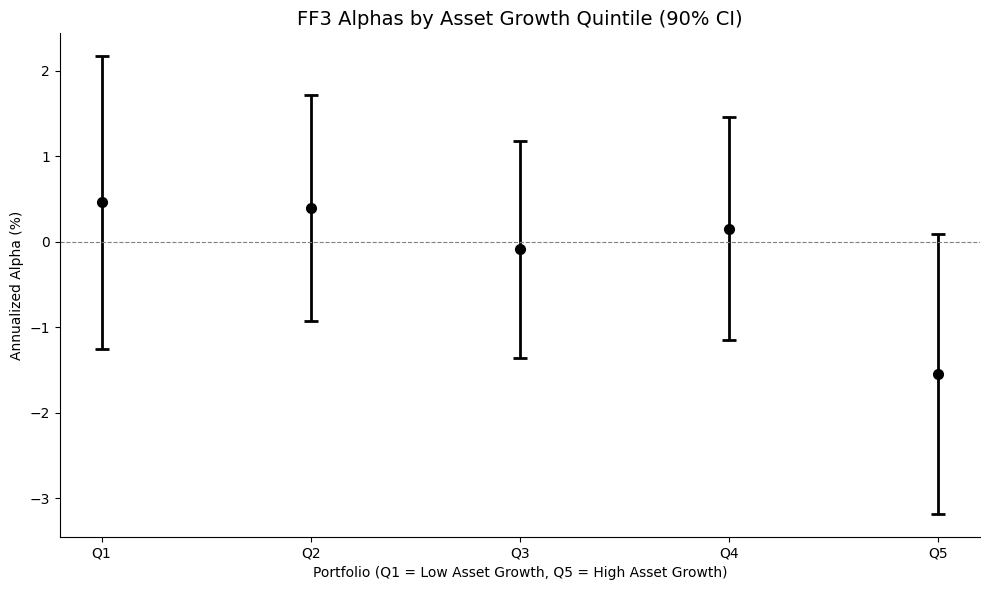

In [ ]:
###############################################################################
# Step 4e: Plot FF3 Alphas with 90% Confidence Intervals
###############################################################################

# Ensure regression inputs are numeric
for col in ['ExMkt', 'SMB', 'HML'] + [f'ExRet_{i}' for i in range(nportfolios)]:
    portfolios_ff[col] = pd.to_numeric(portfolios_ff[col], errors='coerce')

alpha_data = []
for i, p in enumerate(port_cols[:5]):
    y = pd.to_numeric(portfolios_ff['ExRet_'+p], errors='coerce')
    x = portfolios_ff[['ExMkt', 'SMB', 'HML']].apply(pd.to_numeric, errors='coerce')
    reg_data = pd.concat([y.rename('y'), x], axis=1).dropna()

    results = sm.OLS(reg_data['y'], sm.add_constant(reg_data[['ExMkt', 'SMB', 'HML']])).fit()
    alpha_ann = results.params['const'] * 12 * 100
    # 90% CI
    ci = results.conf_int(alpha=0.10).loc['const'] * 12 * 100
    ci_half = (ci[1] - ci[0]) / 2
    alpha_data.append(('Q' + str(i + 1), alpha_ann, ci_half))

fig, ax = plt.subplots(figsize=(10, 6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
names = [d[0] for d in alpha_data]
alphas = [d[1] for d in alpha_data]
cis = [d[2] for d in alpha_data]
ax.errorbar(names, alphas, yerr=cis, fmt='o', color='black',
            capsize=5, elinewidth=2, markeredgewidth=2)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('FF3 Alphas by Asset Growth Quintile (90% CI)', fontsize=14)
ax.set_ylabel('Annualized Alpha (%)')
ax.set_xlabel('Portfolio (Q1 = Low Asset Growth, Q5 = High Asset Growth)')
plt.tight_layout()
plt.show()

---
## Step 5: Compare with Ken French Portfolios

French publishes pre-built "Portfolios Formed on Investment" using the same
definition: (AT_{t-1} − AT_{t-2}) / AT_{t-2}, with NYSE breakpoints and VW returns.

Your portfolios are very close in time-series behavior (correlations ~0.95–0.96) but have lower annualized means by about 1.2–1.5 pp per quintile; long-short difference is small (-0.09 pp).

In [ ]:
###############################################################################
# Step 5: Compare with Ken French Investment Portfolios
###############################################################################

kf_vw = pd.read_csv('Ken French_Portfolios_Formed_on_INV_196307-202601.csv',
                     skiprows=17, nrows=753, header=0)
kf_vw.columns = kf_vw.columns.str.strip()
kf_vw = kf_vw.rename(columns={kf_vw.columns[0]: 'date'})
kf_vw['date'] = pd.to_numeric(kf_vw['date'], errors='coerce')
kf_vw = kf_vw.dropna(subset=['date'])
kf_vw['date'] = kf_vw['date'].astype(int)

# Keep quintiles, convert percent to decimal
kf_quintiles = kf_vw[['date', 'Lo 20', 'Qnt 2', 'Qnt 3', 'Qnt 4', 'Hi 20']].copy()
for col in ['Lo 20', 'Qnt 2', 'Qnt 3', 'Qnt 4', 'Hi 20']:
    kf_quintiles[col] = pd.to_numeric(kf_quintiles[col], errors='coerce') / 100
kf_quintiles['KF_LS'] = kf_quintiles['Lo 20'] - kf_quintiles['Hi 20']

kf_quintiles['year'] = kf_quintiles['date'] // 100
kf_quintiles['month'] = kf_quintiles['date'] % 100

# Merge on overlapping dates
our_data = portfolios.copy()
our_data['year'] = our_data.index.year
our_data['month'] = our_data.index.month
comparison = pd.merge(our_data, kf_quintiles, on=['year', 'month'])

# Comparison table
compare_table = pd.DataFrame(index=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)', 'L-S'])
our_cols = ['0', '1', '2', '3', '4', 'LS']
kf_cols = ['Lo 20', 'Qnt 2', 'Qnt 3', 'Qnt 4', 'Hi 20', 'KF_LS']

compare_table['Ours (ann %)'] = [((1 + comparison[c].mean())**12 - 1)*100 for c in our_cols]
compare_table['French (ann %)'] = [((1 + comparison[c].mean())**12 - 1)*100 for c in kf_cols]
compare_table['Diff (pp)'] = compare_table['Ours (ann %)'] - compare_table['French (ann %)']
compare_table['Correlation'] = [comparison[our_cols[i]].corr(comparison[kf_cols[i]]) for i in range(6)]

print('=== Comparison: Our Portfolios vs. Ken French ===')
print('(Same sample period, both value-weighted)\n')
print(compare_table.round(3).to_string())

=== Comparison: Our Portfolios vs. Ken French ===
(Same sample period, both value-weighted)

           Ours (ann %)  French (ann %)  Diff (pp)  Correlation
Q1 (Low)         13.592          14.922     -1.330        0.959
Q2               12.710          13.973     -1.263        0.960
Q3               12.170          13.623     -1.453        0.959
Q4               12.459          13.947     -1.488        0.960
Q5 (High)        10.877          12.080     -1.203        0.958
L-S               2.470           2.560     -0.090        0.952


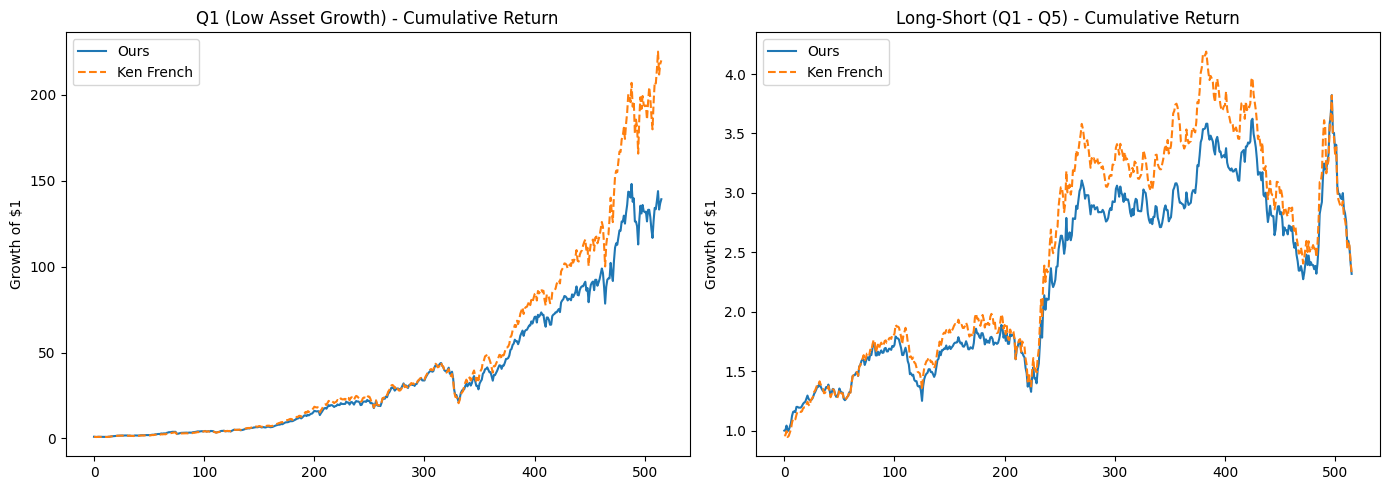

In [ ]:
###############################################################################
# Step 5b: Cumulative return plots
###############################################################################

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q1 comparison
ax = axes[0]
ax.plot((1 + comparison['0']).cumprod().values, label='Ours', linewidth=1.5)
ax.plot((1 + comparison['Lo 20']).cumprod().values, label='Ken French', linewidth=1.5, linestyle='--')
ax.set_title('Q1 (Low Asset Growth) - Cumulative Return')
ax.legend()
ax.set_ylabel('Growth of $1')

# Long-Short comparison
ax = axes[1]
kf_ls = comparison['Lo 20'] - comparison['Hi 20']
ax.plot((1 + comparison['LS']).cumprod().values, label='Ours', linewidth=1.5)
ax.plot((1 + kf_ls).cumprod().values, label='Ken French', linewidth=1.5, linestyle='--')
ax.set_title('Long-Short (Q1 - Q5) - Cumulative Return')
ax.legend()
ax.set_ylabel('Growth of $1')

plt.tight_layout()
plt.show()

---
## Extension 1: Double Sort - Asset Growth x Size

**Research question:** Is the asset growth anomaly stronger in small firms?

Effect is stronger in small stocks: Small_LS mean 3.67% with FF3 alpha 3.11% (p=0.005), versus Big_LS mean 2.41% with alpha 1.91% (p=0.150).

Hou, Xue & Zhang (2020) argue many anomalies are driven by microcaps.
We sort stocks independently into 2 size groups (Small/Big, NYSE median) and
5 asset growth quintiles, creating a 2x5 grid.

In [ ]:
###############################################################################
# Extension 1: Double Sort - Asset Growth x Size (2 x 5)
###############################################################################
print("Extension 1: Double Sort (Asset Growth x Size)")
t = time.time()

june_mktcap = crsp[crsp['month'] == 6][['permno', 'year', 'mktcap', 'exchcd']].copy()
june_mktcap = june_mktcap.dropna(subset=['mktcap'])
june_mktcap = june_mktcap.drop_duplicates(subset=['permno', 'year'])

double_sort_portfolios = []

for year in range(1981, 2024):
    if year % 10 == 0:
        print(f'  Processing {year}...')

    permno_list = list(crsp[crsp['year'] == year - 1]['permno'].unique())
    sorting_data = ccm.loc[
        (ccm['year'] == (year - 1)) & (ccm['lpermno'].isin(permno_list)),
        ['gvkey', 'lpermno', 'change_in_assets']
    ].copy()
    sorting_data = sorting_data.dropna(subset=['change_in_assets'])

    june_data = june_mktcap[june_mktcap['year'] == year][['permno', 'mktcap', 'exchcd']]
    sorting_data = sorting_data.merge(
        june_data, left_on='lpermno', right_on='permno', how='inner'
    )
    if len(sorting_data[sorting_data['exchcd'] == 1]) < 20:
        continue

    nyse = sorting_data[sorting_data['exchcd'] == 1]
    size_median = nyse['mktcap'].median()
    ag_breakpoints = nyse['change_in_assets'].quantile(quantile_breaks).values

    sorting_data['size_group'] = np.where(sorting_data['mktcap'] <= size_median, 'Small', 'Big')
    sorting_data['ag_rank'] = pd.cut(
        sorting_data['change_in_assets'],
        bins=[-np.inf] + list(ag_breakpoints) + [np.inf], labels=False
    )

    crsp_window = crsp[
        ((crsp['year'] == year) & (crsp['month'] >= 7)) |
        ((crsp['year'] == year + 1) & (crsp['month'] <= 6))
    ]

    window_results = []
    for size_grp in ['Small', 'Big']:
        for ag in range(nportfolios):
            basket = sorting_data.loc[
                (sorting_data['size_group'] == size_grp) &
                (sorting_data['ag_rank'] == ag), 'lpermno'
            ].tolist()
            crsp_p = crsp_window[crsp_window['permno'].isin(basket)]
            returns = crsp_p.pivot_table(index='date', columns='permno', values='ret')
            mktcaps = crsp_p.pivot_table(index='date', columns='permno', values='mktcap')
            mktcap_lag = mktcaps.shift(1)
            w = mktcap_lag.div(mktcap_lag.sum(axis=1), axis=0)
            ret_port = (returns * w).sum(axis=1)
            ret_port.name = f'{size_grp}_Q{ag+1}'
            window_results.append(ret_port)

    window_df = pd.concat(window_results, axis=1)
    double_sort_portfolios.append(window_df)

double_sort = pd.concat(double_sort_portfolios, axis=0)
double_sort['Small_LS'] = double_sort['Small_Q1'] - double_sort['Small_Q5']
double_sort['Big_LS'] = double_sort['Big_Q1'] - double_sort['Big_Q5']

print(f'\nDouble sort shape: {double_sort.shape}')
print('Extension 1 completed in %.1fs' % (time.time() - t))

Extension 1: Double Sort (Asset Growth x Size)
  Processing 1990...
  Processing 2000...
  Processing 2010...
  Processing 2020...

Double sort shape: (516, 12)
Extension 1 completed in 10.5s


In [ ]:
###############################################################################
# Extension 1b: Analyze double sort results
###############################################################################

ds_ff = double_sort.copy()
ds_ff['year'] = ds_ff.index.year
ds_ff['month'] = ds_ff.index.month
ds_ff = pd.merge(ds_ff, ff, on=['year', 'month'])

# Ensure FF factors are numeric before regressions
for col in ['ExMkt', 'SMB', 'HML']:
    ds_ff[col] = pd.to_numeric(ds_ff[col], errors='coerce')

print('=== Double Sort: Annualized Mean Returns (%) ===')
for grp, label in [('Small', 'Small Stocks'), ('Big', 'Big Stocks')]:
    cols = [f'{grp}_Q{i}' for i in range(1, 6)] + [f'{grp}_LS']
    means = ((1 + double_sort[cols].mean()) ** 12 - 1) * 100
    print(f'\n{label}:')
    print(means.round(2).to_string())

print('\n=== FF3 Alpha for Long-Short by Size ===')
for label, col in [('Small', 'Small_LS'), ('Big', 'Big_LS')]:
    # L-S is already a zero-cost portfolio — do NOT subtract RF
    y = pd.to_numeric(ds_ff[col], errors='coerce')
    x = ds_ff[['ExMkt', 'SMB', 'HML']].apply(pd.to_numeric, errors='coerce')
    reg_data = pd.concat([y.rename('y'), x], axis=1).dropna()
    results = sm.OLS(reg_data['y'], sm.add_constant(reg_data[['ExMkt', 'SMB', 'HML']])).fit()
    print(f'{label}: Alpha = {results.params["const"]*12*100:.2f}% '
          f'(t={results.tvalues["const"]:.2f}, p={results.pvalues["const"]:.3f})')

=== Double Sort: Annualized Mean Returns (%) ===

Small Stocks:
Small_Q1    14.45
Small_Q2    14.81
Small_Q3    15.18
Small_Q4    14.27
Small_Q5    10.43
Small_LS     3.67

Big Stocks:
Big_Q1    13.84
Big_Q2    12.49
Big_Q3    11.95
Big_Q4    12.36
Big_Q5    11.18
Big_LS     2.41

=== FF3 Alpha for Long-Short by Size ===
Small: Alpha = 3.11% (t=2.85, p=0.005)
Big: Alpha = 1.91% (t=1.44, p=0.150)


---
## Extension 2: Within-Industry Analysis (Post-1990)

**Research question:** Is the asset growth anomaly a firm-level or industry-level effect?

After industry-adjusting asset growth, performance turns negative: mean return -1.70% and FF3 alpha -0.53%.

The industry-adjusted alpha is clearly not significant (p = 0.700), so the anomaly does not survive within-industry sorting.

That means the original signal seems to be driven largely by between-industry differences, not firm-specific deviations within industries.

We demean asset growth by FF-12 industry, then sort on the residual.
If the anomaly survives, it reflects firm-level deviations from industry norms.

In [ ]:
###############################################################################
# Extension 2: Within-Industry Sort (Post-1990)
###############################################################################
print("Extension 2: Within-Industry Analysis")
t = time.time()

industry_portfolios = []

for year in range(1990, 2024):
    if year % 10 == 0:
        print(f'  Processing {year}...')

    permno_list = list(crsp[crsp['year'] == year - 1]['permno'].unique())
    sorting_data = ccm.loc[
        (ccm['year'] == (year - 1)) & (ccm['lpermno'].isin(permno_list)),
        ['gvkey', 'lpermno', 'change_in_assets', 'ff12']
    ].copy()
    sorting_data = sorting_data.dropna(subset=['change_in_assets', 'ff12'])

    # Industry-demean asset growth
    sorting_data['industry_mean'] = sorting_data.groupby('ff12')['change_in_assets'].transform('mean')
    sorting_data['adj_ag'] = sorting_data['change_in_assets'] - sorting_data['industry_mean']

    exchcd_june = crsp[
        (crsp['year'] == year) & (crsp['month'] == 6)
    ][['permno', 'exchcd']].drop_duplicates(subset=['permno'])
    sorting_data = sorting_data.merge(
        exchcd_june, left_on='lpermno', right_on='permno', how='left'
    )

    nyse_data = sorting_data[sorting_data['exchcd'] == 1]['adj_ag']
    if len(nyse_data) < 20:
        continue
    breakpoints = nyse_data.quantile(quantile_breaks).values
    sorting_data['rank'] = pd.cut(
        sorting_data['adj_ag'],
        bins=[-np.inf] + list(breakpoints) + [np.inf], labels=False
    )

    crsp_window = crsp[
        ((crsp['year'] == year) & (crsp['month'] >= 7)) |
        ((crsp['year'] == year + 1) & (crsp['month'] <= 6))
    ]

    window_results = []
    for p in range(nportfolios):
        basket = sorting_data.loc[sorting_data['rank'] == p, 'lpermno'].tolist()
        crsp_p = crsp_window[crsp_window['permno'].isin(basket)]
        returns = crsp_p.pivot_table(index='date', columns='permno', values='ret')
        mktcaps = crsp_p.pivot_table(index='date', columns='permno', values='mktcap')
        mktcap_lag = mktcaps.shift(1)
        w = mktcap_lag.div(mktcap_lag.sum(axis=1), axis=0)
        ret_port = (returns * w).sum(axis=1)
        ret_port.name = str(p)
        window_results.append(ret_port)

    window_df = pd.concat(window_results, axis=1)
    industry_portfolios.append(window_df)

ind_portfolios = pd.concat(industry_portfolios, axis=0)
ind_portfolios['LS'] = ind_portfolios['0'] - ind_portfolios['4']

print(f'\nIndustry-adjusted portfolio shape: {ind_portfolios.shape}')
print('Extension 2 completed in %.1fs' % (time.time() - t))

Extension 2: Within-Industry Analysis
  Processing 1990...
  Processing 2000...
  Processing 2010...
  Processing 2020...

Industry-adjusted portfolio shape: (408, 6)
Extension 2 completed in 6.7s


In [ ]:
###############################################################################
# Extension 2b: Compare raw vs. industry-adjusted (post-1990)
###############################################################################

ind_ff = ind_portfolios.copy()
ind_ff['year'] = ind_ff.index.year
ind_ff['month'] = ind_ff.index.month
ind_ff = pd.merge(ind_ff, ff, on=['year', 'month'])

raw_post90 = portfolios[portfolios.index >= '1990-07-01'].copy()
raw_post90_ff = raw_post90.copy()
raw_post90_ff['year'] = raw_post90_ff.index.year
raw_post90_ff['month'] = raw_post90_ff.index.month
raw_post90_ff = pd.merge(raw_post90_ff, ff, on=['year', 'month'])

# Ensure FF factors are numeric before regressions
for col in ['ExMkt', 'SMB', 'HML']:
    ind_ff[col] = pd.to_numeric(ind_ff[col], errors='coerce')
    raw_post90_ff[col] = pd.to_numeric(raw_post90_ff[col], errors='coerce')

print('=== Comparison: Raw vs. Industry-Adjusted Long-Short (Post-1990) ===')

# Raw L-S (zero-cost portfolio — do NOT subtract RF)
raw_reg = pd.concat([
    pd.to_numeric(raw_post90_ff['LS'], errors='coerce').rename('y'),
    raw_post90_ff[['ExMkt', 'SMB', 'HML']].apply(pd.to_numeric, errors='coerce')
], axis=1).dropna()
res_raw = sm.OLS(raw_reg['y'],
                 sm.add_constant(raw_reg[['ExMkt', 'SMB', 'HML']])).fit()

# Industry-adjusted L-S (also zero-cost)
ind_reg = pd.concat([
    pd.to_numeric(ind_ff['LS'], errors='coerce').rename('y'),
    ind_ff[['ExMkt', 'SMB', 'HML']].apply(pd.to_numeric, errors='coerce')
], axis=1).dropna()
res_ind = sm.OLS(ind_reg['y'],
                 sm.add_constant(ind_reg[['ExMkt', 'SMB', 'HML']])).fit()

comp = pd.DataFrame({
    'Raw': {
        'Mean Return (ann %)': ((1 + raw_post90['LS'].mean())**12 - 1)*100,
        'FF3 Alpha (ann %)': res_raw.params['const']*12*100,
        'Alpha t-stat': res_raw.tvalues['const'],
        'Alpha p-val': res_raw.pvalues['const'],
    },
    'Industry-Adjusted': {
        'Mean Return (ann %)': ((1 + ind_portfolios['LS'].mean())**12 - 1)*100,
        'FF3 Alpha (ann %)': res_ind.params['const']*12*100,
        'Alpha t-stat': res_ind.tvalues['const'],
        'Alpha p-val': res_ind.pvalues['const'],
    }
})
print(comp.round(4).to_string())
print('\nIf industry-adjusted alpha remains significant, the anomaly reflects')
print('firm-level deviations from industry norms, not just industry effects.')

=== Comparison: Raw vs. Industry-Adjusted Long-Short (Post-1990) ===
                        Raw  Industry-Adjusted
Mean Return (ann %)  1.5818            -1.7038
FF3 Alpha (ann %)    1.9040            -0.5336
Alpha t-stat         1.3588            -0.3858
Alpha p-val          0.1750             0.6999

If industry-adjusted alpha remains significant, the anomaly reflects
firm-level deviations from industry norms, not just industry effects.


---
## Summary

This notebook implements:

1. **Main Analysis**: Univariate asset growth quintile sort with NYSE-only breakpoints
   and value-weighted returns, with CAPM and FF3 performance evaluation

2. **Comparison with Ken French**: Direct comparison vs. French's pre-built
   "Portfolios Formed on Investment"

3. **Extension 1 (Double Sort)**: Asset Growth x Size, testing the Hou, Xue &
   Zhang (2020) microcap critique

4. **Extension 2 (Industry Analysis)**: Within-industry sort, testing whether the
   effect is firm-level or industry-level